# Fractional Differencing

**Docker image**: `ml4t`

This notebook demonstrates **fractional differentiation** (FFD), a technique that
achieves stationarity while preserving as much memory as possible.

**Learning Objectives**:
- Understand the memory-stationarity tradeoff controlled by $d \in (0, 1)$
- Compute FFD weights and apply fractional differencing via ml4t-engineer
- Select $d$ by asset class using bounded grids (no in-sample search)
- Validate stationarity with ADF and quantify sample loss

**Book Reference**: Chapter 9, Section 9.1 (Diagnostics and Stationarity Features)

**Prerequisites**: `01_visual_diagnostics` for stationarity testing concepts.

In [1]:
"""Fractional Differencing - achieve stationarity while preserving memory."""

import warnings
from typing import Any, cast

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

from ml4t.engineer.features.fdiff import (
    fdiff_diagnostics,
    ffdiff,
    find_optimal_d,
    get_ffd_weights,
)

from data import load_etfs
from utils.style import COLORS

# Weight-truncation threshold for FFD. A single source of truth so the demo
# grid, the weight plots, and the validity mask all use the same window widths.
FFD_THRESHOLD = 1e-4

In [2]:
# Production defaults - Papermill injects overrides for CI
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"

In [3]:
# Load data
all_etfs = load_etfs()

## 1. Load Data

In [4]:
def load_etf_data(symbol: str, start: str = START_DATE, end: str = END_DATE) -> pl.DataFrame:
    """Load ETF data from cached parquet."""
    df = (
        all_etfs.filter(pl.col("symbol") == symbol)
        .filter(pl.col("timestamp") >= pl.lit(start).str.to_date())
        .filter(pl.col("timestamp") <= pl.lit(end).str.to_date())
        .sort("timestamp")
    )
    return df


# Load SPY for demonstration
spy = load_etf_data("SPY")
print(f"SPY: {len(spy)} days")

SPY: 2264 days


## 2. Bounded d Grid (Default Workflow)

Rather than searching for "optimal d", use **fixed grids by asset class**.
This is simpler, more robust, and avoids overfitting to in-sample data.

### Recommended d Values by Asset Class

| Asset Class | Recommended d | Rationale |
|-------------|---------------|-----------|
| **US Equities** | 0.4 | Moderate persistence |
| **Fixed Income** | 0.5 | High persistence (rates) |
| **Crypto** | 0.5-0.6 | Strong trending |
| **Commodities** | 0.4 | Similar to equities |
| **FX** | 0.3-0.4 | Mean-reverting tendency |

These are starting points. The exact value matters less than being consistent
and avoiding lookahead from searching on the full sample.

In [5]:
# Asset class d recommendations
ASSET_CLASS_D = {
    "equities": 0.4,
    "fixed_income": 0.5,
    "crypto": 0.5,
    "commodities": 0.4,
    "fx": 0.35,
}

# For teaching: small fixed grid (not search). The grid brackets the
# stationarity crossing so the memory-vs-stationarity tradeoff is visible.
TEACHING_D_GRID = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

print("Asset Class d Recommendations:")
for asset, d in ASSET_CLASS_D.items():
    print(f"  {asset:15s}: d = {d}")

Asset Class d Recommendations:
  equities       : d = 0.4
  fixed_income   : d = 0.5
  crypto         : d = 0.5
  commodities    : d = 0.4
  fx             : d = 0.35


## 3. FFD with Validity Mask and Sample Loss

`ml4t.engineer.features.fdiff.ffdiff` is a **boundary-partial** implementation:
it applies whatever weights are available near the start of the sample, so it
never returns nulls and preserves the row count. The earliest observations are
therefore produced by a shorter effective filter than later ones. The
**full-window** convention (López de Prado) instead treats those warmup rows as
unavailable until the required lookback has accumulated.

We impose the full-window convention explicitly with a **validity mask**: the
window width is the number of FFD weights, and the first `width - 1` rows -
which lack a full window of history - are marked invalid and excluded from every
diagnostic. The output format is:
- **transformed**: The FFD series, warmup rows set to null
- **valid**: Boolean mask (True where a full window of history is available)
- **sample_loss**: Number of warmup observations dropped (`width - 1`)

In [6]:
def ffd_with_diagnostics(
    series: pl.Series, d: float, threshold: float = FFD_THRESHOLD
) -> dict[str, pl.Series | int | float]:
    """
    Apply FFD and return transformed series with validity mask and diagnostics.

    The library ``ffdiff`` is boundary-partial (no nulls). We recover the
    full-window convention by nulling the first ``width - 1`` observations, where
    ``width`` is the number of FFD weights - those rows are the warmup where the
    fixed-width filter does not yet have a full lookback.

    Parameters
    ----------
    series : pl.Series
        Input series (typically log prices)
    d : float
        Differentiation order
    threshold : float
        Weight cutoff threshold

    Returns
    -------
    dict with:
        - transformed: FFD series with warmup rows set to null
        - valid: Boolean mask (True on full-window rows)
        - sample_loss: Number of warmup observations dropped (width - 1)
        - d: The d value used
        - n_weights: Number of FFD weights (the window width)
    """
    # Get weights to determine the fixed window width / warmup period
    weights = get_ffd_weights(d, threshold=threshold)
    width = len(weights)

    # Apply the (boundary-partial) library FFD, then impose the full-window mask:
    # the first width - 1 rows lack a complete lookback and are warmup.
    arr = ffdiff(series, d=d, threshold=threshold).to_numpy().copy()
    valid = np.zeros(len(arr), dtype=bool)
    valid[width - 1 :] = True
    valid &= ~np.isnan(arr)
    arr[~valid] = np.nan

    sample_loss = int((~valid).sum())

    # fill_nan(None) turns the warmup NaNs into proper Polars nulls so drop_nulls()
    # and downstream mask-based filtering behave as expected (Polars keeps NaN and
    # null distinct - drop_nulls does not drop NaN).
    return {
        "transformed": pl.Series(series.name, arr).fill_nan(None),
        "valid": pl.Series("valid", valid),
        "sample_loss": sample_loss,
        "d": d,
        "n_weights": width,
    }

In [7]:
# Apply FFD to SPY log prices with recommended d for equities
log_prices = spy["close"].log()
d_equity = ASSET_CLASS_D["equities"]

ffd_result = ffd_with_diagnostics(log_prices, d=d_equity)
ffd_valid = cast(pl.Series, ffd_result["valid"])
ffd_transformed = cast(pl.Series, ffd_result["transformed"])

print(f"FFD Results (d={d_equity}):")
print(f"  Total observations: {len(log_prices)}")
print(f"  Valid observations: {ffd_valid.sum()}")
print(
    f"  Sample loss: {ffd_result['sample_loss']} ({100 * ffd_result['sample_loss'] / len(log_prices):.1f}%)"
)
print(f"  FFD weights used: {ffd_result['n_weights']}")

FFD Results (d=0.4):
  Total observations: 2264
  Valid observations: 1983
  Sample loss: 281 (12.4%)
  FFD weights used: 282


## 4. Compare d Values from Grid

Show how different d values affect stationarity and memory preservation.

In [8]:
# Apply grid of d values
grid_results = {}

for d in TEACHING_D_GRID:
    result = ffd_with_diagnostics(log_prices, d=d)
    transformed = cast(pl.Series, result["transformed"])
    valid = cast(pl.Series, result["valid"])

    # Quick stationarity check (for display only)
    clean = transformed.drop_nulls().to_numpy()
    if len(clean) > 50:
        adf_stat, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")

        # Correlation with original (memory preserved)
        valid_mask = valid.to_numpy()
        orig = log_prices.to_numpy()[valid_mask]
        ffd = transformed.to_numpy()[valid_mask]
        corr = np.corrcoef(orig, ffd)[0, 1]

        grid_results[d] = {
            "sample_loss": result["sample_loss"],
            "adf_pval": adf_pval,
            "correlation": corr,
            "n_weights": result["n_weights"],
        }

grid_df = pd.DataFrame(
    [
        {
            "d": d,
            "sample_loss": res["sample_loss"],
            "adf_pval": res["adf_pval"],
            "stationary": res["adf_pval"] < 0.05,
            "corr_with_orig": res["correlation"],
            "n_weights": res["n_weights"],
        }
        for d, res in grid_results.items()
    ]
)
display(grid_df)

,d,sample_loss,adf_pval,stationary,corr_with_orig,n_weights
0,0.1,502,5.303648e-01,False,0.992543,503
1,0.2,496,2.010753e-01,False,0.956875,497
2,0.3,387,3.203806e-02,True,0.897159,388
3,0.4,281,5.988241e-04,True,0.808553,282
4,0.5,199,1.164976e-05,True,0.688806,200
5,0.6,139,5.347082e-09,True,0.540988,140


The table reads top to bottom as the memory-stationarity tradeoff. As $d$ rises,
`corr_with_orig` falls **monotonically** - the transform keeps less of the
original level's memory - while the ADF p-value collapses toward zero. On this
SPY sample the series first tests stationary around $d \approx 0.3$, and the
equities default $d = 0.4$ is comfortably stationary while still retaining
roughly 0.8 correlation with the original level. Note also that a lower $d$ needs
a **wider** window (`n_weights`), so honest full-window handling drops more
warmup rows (`sample_loss`): stationarity and memory are both bought with data.

## 5. Visualize FFD Weights

FFD weights determine how much memory is preserved. Every weight sequence starts
at $w_0 = 1$; the memory difference lives in the **tail**. Plotting the weight
magnitude on a log scale (skipping $w_0$) makes the decay rate visible: a lower
$d$ keeps larger weights on more distant lags, and its window (where the weights
finally fall below the truncation threshold) extends further into the past.

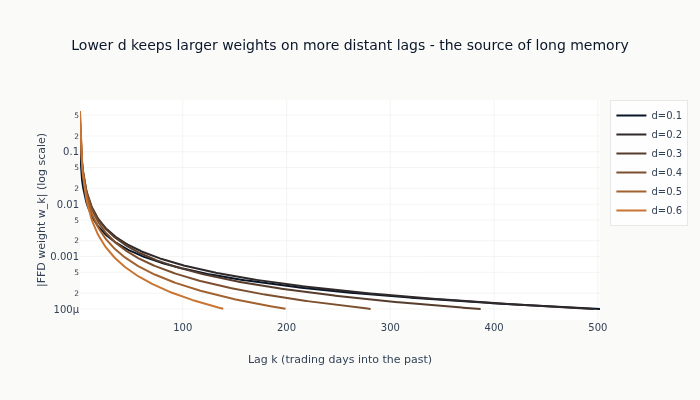


Weight Counts (threshold=1e-04):
  d=0.1: 503 weights
  d=0.2: 497 weights
  d=0.3: 388 weights
  d=0.4: 282 weights
  d=0.5: 200 weights
  d=0.6: 140 weights


In [9]:
# Blue -> copper gradient ordered by d (dark = low d / long memory, warm = high d).
def _hex_gradient(c0: str, c1: str, n: int) -> list[str]:
    lo = np.array([int(c0[i : i + 2], 16) for i in (1, 3, 5)])
    hi = np.array([int(c1[i : i + 2], 16) for i in (1, 3, 5)])
    out = []
    for t in np.linspace(0, 1, n):
        r, g, b = (lo + (hi - lo) * t).astype(int)
        out.append(f"#{r:02x}{g:02x}{b:02x}")
    return out


d_colors = _hex_gradient(COLORS["blue"], COLORS["copper"], len(TEACHING_D_GRID))

# Visualize weight magnitude (log scale) for different d values
fig = go.Figure()

for d, color in zip(TEACHING_D_GRID, d_colors):
    weights = get_ffd_weights(d, threshold=FFD_THRESHOLD)
    # Skip w_0 = 1 (identical for every d); the memory difference is in the tail.
    fig.add_trace(
        go.Scatter(
            x=list(range(1, len(weights))),
            y=np.abs(weights[1:]),
            mode="lines",
            name=f"d={d}",
            line=dict(color=color, width=2),
        )
    )

fig.update_layout(
    height=400,
    title="Lower d keeps larger weights on more distant lags - the source of long memory",
    xaxis_title="Lag k (trading days into the past)",
    yaxis_title="|FFD weight w_k| (log scale)",
    yaxis=dict(type="log"),
)
fig.show()

# Weight counts
print(f"\nWeight Counts (threshold={FFD_THRESHOLD:.0e}):")
for d in TEACHING_D_GRID:
    weights = get_ffd_weights(d, threshold=FFD_THRESHOLD)
    print(f"  d={d}: {len(weights)} weights")

## 6. Feature Engineering Output Format

Standard format for downstream ML: transformed series + validity mask.

In [10]:
# Create feature table with FFD at recommended d
spy_features = spy.select(["timestamp", "close"]).with_columns(
    [
        pl.col("close").log().alias("log_close"),
        pl.col("close").pct_change().alias("return_1d"),
    ]
)

# Add FFD with recommended d
d_use = ASSET_CLASS_D["equities"]
ffd_result = ffd_with_diagnostics(spy_features["log_close"], d=d_use)
ffd_transformed = cast(pl.Series, ffd_result["transformed"])
ffd_valid = cast(pl.Series, ffd_result["valid"])

spy_features = spy_features.with_columns(
    [
        ffd_transformed.alias(f"ffd_{d_use}"),
        ffd_valid.alias("ffd_valid"),
    ]
)

# Show sample loss prominently
print(f"Feature Engineering Output (d={d_use}):")
print(f"  Total rows: {spy_features.height}")
print(f"  Valid rows: {ffd_valid.sum()}")
print(f"  Sample loss: {ffd_result['sample_loss']} observations")
print()

Feature Engineering Output (d=0.4):
  Total rows: 2264
  Valid rows: 1983
  Sample loss: 281 observations



The feature table below shows the last 10 valid rows. Note the `ffd_valid`
column - downstream ML pipelines should filter on this mask to exclude the
warmup period where FFD weights require more history than is available.

In [11]:
print("Feature Table (valid rows):")
spy_features.filter(pl.col("ffd_valid")).tail(10)

Feature Table (valid rows):


timestamp,close,log_close,return_1d,ffd_0.4,ffd_valid
date,f64,f64,f64,f64,bool
2023-12-15,456.760101,6.124158,-0.001647,0.450267,true
2023-12-18,459.329468,6.129768,0.005625,0.454553,true
2023-12-19,462.122559,6.13583,0.006081,0.457201,true
2023-12-20,455.718842,6.121876,-0.013857,0.439206,true
2023-12-21,460.039886,6.131313,0.009482,0.452354,true
2023-12-22,460.964417,6.133321,0.00201,0.450971,true
2023-12-26,462.910828,6.137534,0.004222,0.453136,true
2023-12-27,463.747833,6.139341,0.001808,0.452167,true
2023-12-28,463.923004,6.139719,0.000378,0.450509,true


## 7. Multi-Asset Application

Apply fixed d values by asset class (no search).

In [12]:
# ETF symbols with asset class mapping
ETF_ASSETS = {
    "SPY": "equities",
    "QQQ": "equities",
    "IWM": "equities",
    "TLT": "fixed_income",
    "GLD": "commodities",
    "EFA": "equities",
    "EEM": "equities",
}

etf_ffd_results = {}

for symbol, asset_class in ETF_ASSETS.items():
    data = load_etf_data(symbol)
    if data.height < 100:
        continue

    d = ASSET_CLASS_D[asset_class]
    log_prices = data["close"].log()
    result = ffd_with_diagnostics(log_prices, d=d)

    # Quick stationarity verification
    clean = cast(pl.Series, result["transformed"]).drop_nulls().to_numpy()
    if len(clean) > 50:
        _, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")

        etf_ffd_results[symbol] = {
            "asset_class": asset_class,
            "d": d,
            "sample_loss": result["sample_loss"],
            "sample_loss_pct": 100 * result["sample_loss"] / data.height,
            "adf_pval": adf_pval,
            "stationary": adf_pval < 0.05,
        }

When building a mixed-portfolio feature set, different asset classes will have
different optimal d values. This is acceptable - each security's FFD features
use its own d, and the ML model learns from the resulting feature distributions.
Consistency within each security over time matters more than uniformity across
securities.

The fixed asset-class d is a **starting point, not a guarantee**: at the equities
default d = 0.4 most names test stationary, but a few (e.g. QQQ and GLD on this
sample) still fail the ADF test at the 0.05 level. That is the expected cost of a
no-search rule - it trades a little per-symbol stationarity for robustness and
no lookahead. Symbols that need more differencing can be bumped one grid step,
still without searching on the full sample.

In [13]:
multi_df = pd.DataFrame([{"symbol": sym, **res} for sym, res in etf_ffd_results.items()])
display(multi_df)

,symbol,asset_class,d,sample_loss,sample_loss_pct,adf_pval,stationary
0,SPY,equities,0.4,281,12.411661,5.988241e-04,True
1,QQQ,equities,0.4,281,12.411661,1.715264e-01,False
2,IWM,equities,0.4,281,12.411661,1.269742e-06,True
3,TLT,fixed_income,0.5,199,8.789753,1.194056e-03,True
4,GLD,commodities,0.4,281,12.411661,7.824284e-02,False
5,EFA,equities,0.4,281,12.411661,8.095041e-07,True
6,EEM,equities,0.4,281,12.411661,7.303398e-08,True


## 8. Visualize FFD Transformation

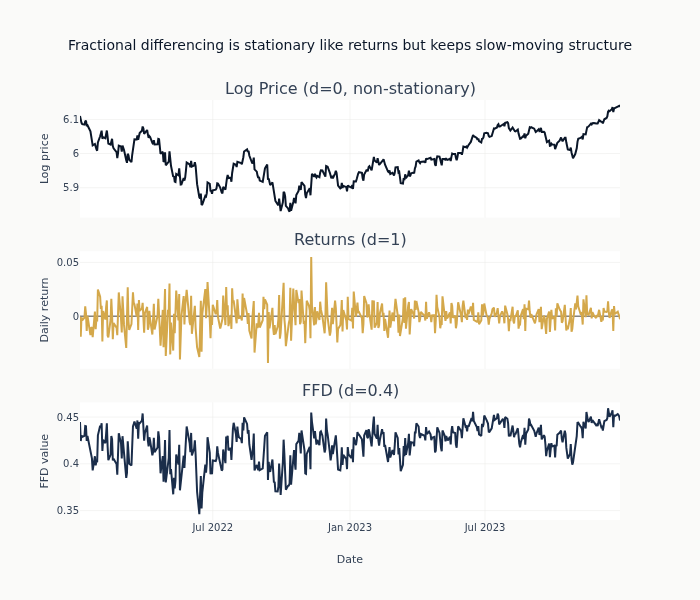

In [14]:
# Compare original, returns, and FFD
d_plot = ASSET_CLASS_D["equities"]
ffd_series = ffdiff(spy["close"].log(), d=d_plot, threshold=FFD_THRESHOLD)

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Log Price (d=0, non-stationary)", "Returns (d=1)", f"FFD (d={d_plot})"],
    vertical_spacing=0.08,
)

dates = spy["timestamp"].to_list()
log_prices_arr = spy["close"].log().to_numpy()
returns_arr = spy["close"].pct_change().to_numpy()
ffd_arr = ffd_series.to_numpy()

# Use last 500 points for visibility
n = 500

fig.add_trace(go.Scatter(x=dates[-n:], y=log_prices_arr[-n:], name="Log Price"), row=1, col=1)
fig.add_trace(go.Scatter(x=dates[-n:], y=returns_arr[-n:], name="Returns"), row=2, col=1)
fig.add_trace(go.Scatter(x=dates[-n:], y=ffd_arr[-n:], name="FFD"), row=3, col=1)

fig.update_yaxes(title_text="Log price", row=1, col=1)
fig.update_yaxes(title_text="Daily return", row=2, col=1)
fig.update_yaxes(title_text="FFD value", row=3, col=1)
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_layout(
    height=600,
    showlegend=False,
    title="Fractional differencing is stationary like returns but keeps slow-moving structure",
)
fig.show()

---

## 9. [OPTIONAL] Walk-Forward d Search

> **WARNING: Research Helper Only**
>
> If you need to search for d, do it with **walk-forward validation**:
> estimate d on training data only, then apply to test data.
> This avoids lookahead bias from using the full sample.

In [15]:
def find_d_walk_forward(
    series: pl.Series,
    train_end_idx: int,
    d_grid: list[float] | None = None,
    adf_threshold: float = 0.05,
) -> dict[str, Any]:
    """Find the smallest $d$ on the grid that makes the series stationary.

    Estimated on training data only - no leakage from the held-out tail. The
    smallest stationary $d$ is the López de Prado convention: keep as much
    long-run dependence as the stationarity diagnostic allows.
    """
    if d_grid is None:
        d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    train_series = series.head(train_end_idx)
    d_grid = sorted(d_grid)

    for d in d_grid:
        # Full-window masked FFD, consistent with the rest of the notebook.
        result = ffd_with_diagnostics(train_series, d=d)
        valid = cast(pl.Series, result["valid"]).to_numpy()
        ffd = cast(pl.Series, result["transformed"]).to_numpy()
        clean = ffd[valid]

        if len(clean) < 50:
            continue

        _, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")
        if adf_pval < adf_threshold:
            corr = np.corrcoef(train_series.to_numpy()[valid], clean)[0, 1]
            return {
                "optimal_d": d,
                "train_adf_pval": adf_pval,
                "train_correlation": corr,
            }

    # No d on the grid produced a stationary series - fall back to first differences.
    return {"optimal_d": 1.0, "train_adf_pval": float("nan"), "train_correlation": 0.0}

In [16]:
# [OPTIONAL] Walk-forward example
# Split: 80% train, 20% test
train_pct = 0.8
train_end = int(len(spy) * train_pct)

print("Walk-forward d search:")
print(f"  Training period: {spy['timestamp'][0]} to {spy['timestamp'][train_end - 1]}")
print(f"  Test period: {spy['timestamp'][train_end]} to {spy['timestamp'][-1]}")
print()

wf_result = find_d_walk_forward(spy["close"].log(), train_end_idx=train_end)

print("Results (estimated on training data ONLY):")
print(f"  Selected d: {wf_result['optimal_d']}")
print(f"  Train ADF p-value: {wf_result['train_adf_pval']:.4f}")
print(f"  Train correlation with original: {wf_result['train_correlation']:.4f}")
print()

# Apply to test data (out-of-sample), same full-window masking
test_series = spy["close"].log().tail(len(spy) - train_end)
ffd_test = cast(
    pl.Series, ffd_with_diagnostics(test_series, d=wf_result["optimal_d"])["transformed"]
)
clean_test = ffd_test.drop_nulls().to_numpy()

if len(clean_test) > 50:
    _, test_pval, _, _, _, _ = adfuller(clean_test, autolag="AIC")
    print("Out-of-sample verification:")
    print(f"  Test ADF p-value: {test_pval:.4f}")
    print(f"  Stationary in test: {'Yes' if test_pval < 0.05 else 'No'}")

Walk-forward d search:
  Training period: 2015-01-02 to 2022-03-11
  Test period: 2022-03-14 to 2023-12-29

Results (estimated on training data ONLY):
  Selected d: 0.4
  Train ADF p-value: 0.0029
  Train correlation with original: 0.8263

Out-of-sample verification:
  Test ADF p-value: 0.0070
  Stationary in test: Yes


### ml4t-engineer: Automated d Selection and Diagnostics

The manual walk-forward search above builds intuition for the
memory-stationarity tradeoff. `find_optimal_d()` automates the grid search and
`fdiff_diagnostics()` provides a comprehensive diagnostic summary.

**Read these numbers against the convention.** These helpers use the library's
**boundary-partial** FFD directly - no validity mask - so their ADF test
includes the warmup rows produced by a partial filter. That makes the series
test stationary at a much smaller $d$ than the full-window analysis above
(Section 4 needed $d \approx 0.3$; `find_optimal_d` reports far less). The
boundary-partial answer is not wrong, it answers a different question: "how much
differencing makes the row-count-preserving transform stationary," warmup rows
included. For features fed to a model that will *drop* the warmup, prefer the
full-window value.

In [17]:
# find_optimal_d: automated grid search
log_prices_series = spy["close"].log()
optimal = find_optimal_d(log_prices_series, d_range=(0.0, 1.0), step=0.05)
print("=== ml4t-engineer: find_optimal_d ===")
print(f"Optimal d: {optimal['optimal_d']:.2f}")
print(f"ADF p-value: {optimal['adf_pvalue']:.4f}")
print(f"Correlation with original: {optimal['correlation']:.4f}")

=== ml4t-engineer: find_optimal_d ===
Optimal d: 0.05
ADF p-value: 0.0088
Correlation with original: 0.5642


In [18]:
# fdiff_diagnostics: detailed analysis at a specific d
diag = fdiff_diagnostics(log_prices_series, d=optimal["optimal_d"])
print("=== ml4t-engineer: fdiff_diagnostics ===")
print(f"d: {diag['d']:.2f}")
print(f"ADF statistic: {diag['adf_statistic']:.4f}")
print(f"ADF p-value: {diag['adf_pvalue']:.4f}")
print(f"Correlation: {diag['correlation']:.4f}")
print(f"Number of weights: {diag['n_weights']}")
print(f"Weight sum: {diag['weight_sum']:.4f}")

=== ml4t-engineer: fdiff_diagnostics ===
d: 0.05
ADF statistic: -3.4682
ADF p-value: 0.0088
Correlation: 0.5642
Number of weights: 3237
Weight sum: 1.3528


**Note**: For the recommended workflow, use **fixed d by asset class** (Section 2).
`find_optimal_d()` is a convenience for exploratory analysis - it searches the
full sample (wrap it in a walk-forward scheme to avoid lookahead bias) and uses
the boundary-partial convention (mask the warmup before trusting its d).

## 10. Distribution Comparison

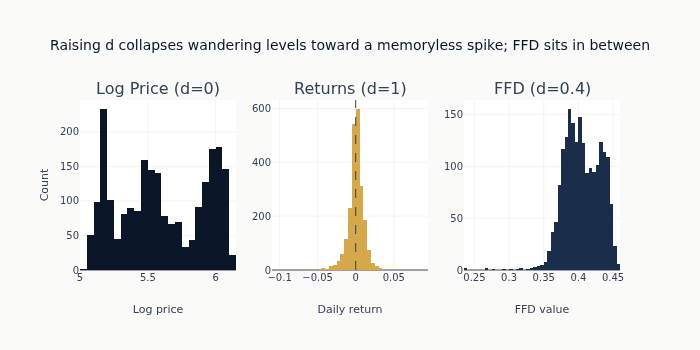

In [19]:
# Compare distributions of different transformations. Use the validity-masked FFD
# so the warmup rows - produced by a partial filter and orders of magnitude larger
# than the differenced values - do not distort the histogram.
d_compare = ASSET_CLASS_D["equities"]
ffd_compare = cast(pl.Series, ffd_with_diagnostics(spy["close"].log(), d=d_compare)["transformed"])

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Log Price (d=0)", "Returns (d=1)", f"FFD (d={d_compare})"],
)

log_vals = spy["close"].log().drop_nulls().to_numpy()
ret_vals = spy["close"].pct_change().drop_nulls().to_numpy()
ffd_vals = ffd_compare.drop_nulls().to_numpy()

fig.add_trace(go.Histogram(x=log_vals, nbinsx=50, name="Log Price"), row=1, col=1)
fig.add_trace(go.Histogram(x=ret_vals, nbinsx=50, name="Returns"), row=1, col=2)
fig.add_trace(go.Histogram(x=ffd_vals, nbinsx=50, name="FFD"), row=1, col=3)

# Zero reference on returns, the one mean-zero transform. FFD (d=0.4) is stationary
# but not mean-zero: finite-width truncation leaves a small residual level, so the
# series centers near 0.4 rather than 0 - a reference at 0 would sit off the data.
fig.add_vline(x=0, line=dict(color=COLORS["neutral"], dash="dash", width=1), row=1, col=2)

fig.update_xaxes(title_text="Log price", row=1, col=1)
fig.update_xaxes(title_text="Daily return", row=1, col=2)
fig.update_xaxes(title_text="FFD value", row=1, col=3)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_layout(
    height=350,
    title="Raising d collapses wandering levels toward a memoryless spike; FFD sits in between",
    showlegend=False,
)
fig.show()

**Finding**: The log price distribution (left) is multimodal and wanders over a
wide range - the signature of non-stationarity. First-differencing all the way to
returns (center) collapses this to a tight, near-symmetric spike at zero: stationary,
but memoryless. FFD at $d = 0.4$ (right) is the intermediate case - a much narrower
distribution than the levels, yet still offset from zero and carrying the level
information that returns discard, while passing the stationarity test.

---

## Summary

### Default Workflow (Recommended)

1. **Use fixed d by asset class** - no search, no lookahead
2. **Output format**: transformed series + validity mask + sample loss count
3. **Verify stationarity** with quick ADF check (but don't optimize on it)

### Asset Class d Recommendations

| Asset Class | d |
|-------------|---|
| US Equities | 0.4 |
| Fixed Income | 0.5 |
| Crypto | 0.5 |
| Commodities | 0.4 |
| FX | 0.35 |

### Note on Sample Loss and the Boundary Convention

`ml4t.engineer.features.fdiff.ffdiff` is **boundary-partial**: it applies
truncated weights at the start rather than NaN-padding, so the raw feature is
non-null from observation 0 but the earliest values use only a partial weight
set. This notebook layers the classical **full-window** convention (López de
Prado, 2018) on top with an explicit validity mask: the first `width - 1` rows,
where `width` is the number of FFD weights, are the warmup and are dropped
before every diagnostic - hence the non-zero `Sample Loss` in the tables above
(e.g. 281 rows / 12.4% at d=0.4 on the SPY sample). Choose the convention
deliberately: the partial form keeps every observation, the full-window form
discards the warmup so no row relies on a shorter filter. All diagnostics here
use the full-window convention; the `find_optimal_d` helper in Section 9 does
not, which is exactly why it reports a smaller d.

### ml4t-engineer Functions

- **`ffdiff(series, d)`**: Apply fractional differentiation
- **`get_ffd_weights(d, threshold)`**: Get FFD weight vector
- **`find_optimal_d(series)`**: Automated grid search for minimum stationary d
- **`fdiff_diagnostics(series, d)`**: ADF, correlation, weight analysis at given d

### Key Points

1. **Always report sample loss** - FFD loses early observations
2. **Use validity mask** for downstream ML pipelines
3. **For walk-forward search** (optional): estimate d on training data only
4. **For stationarity testing details**: see `01_visual_diagnostics`

**Next**: See `04_kalman_filter` for signal transform features and
`05_spectral_features` for frequency-domain features.